## Correlation

In [1]:
path='https://frenzy86.s3.eu-west-2.amazonaws.com/fav/tecno/petrol_consumption.csv'

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(path)
df

,Petrol_tax,Average_income,Paved_Highways,Population_Driver_licence(%),Petrol_Consumption
0,9.00,3571,1976,0.525,541
1,9.00,4092,1250,0.572,524
2,9.00,3865,1586,0.580,561
3,7.50,4870,2351,0.529,414
4,8.00,4399,431,0.544,410
5,10.00,5342,1333,0.571,457
6,8.00,5319,11868,0.451,344
7,8.00,5126,2138,0.553,467
8,8.00,4447,8577,0.529,464
9,7.00,4512,8507,0.552,498


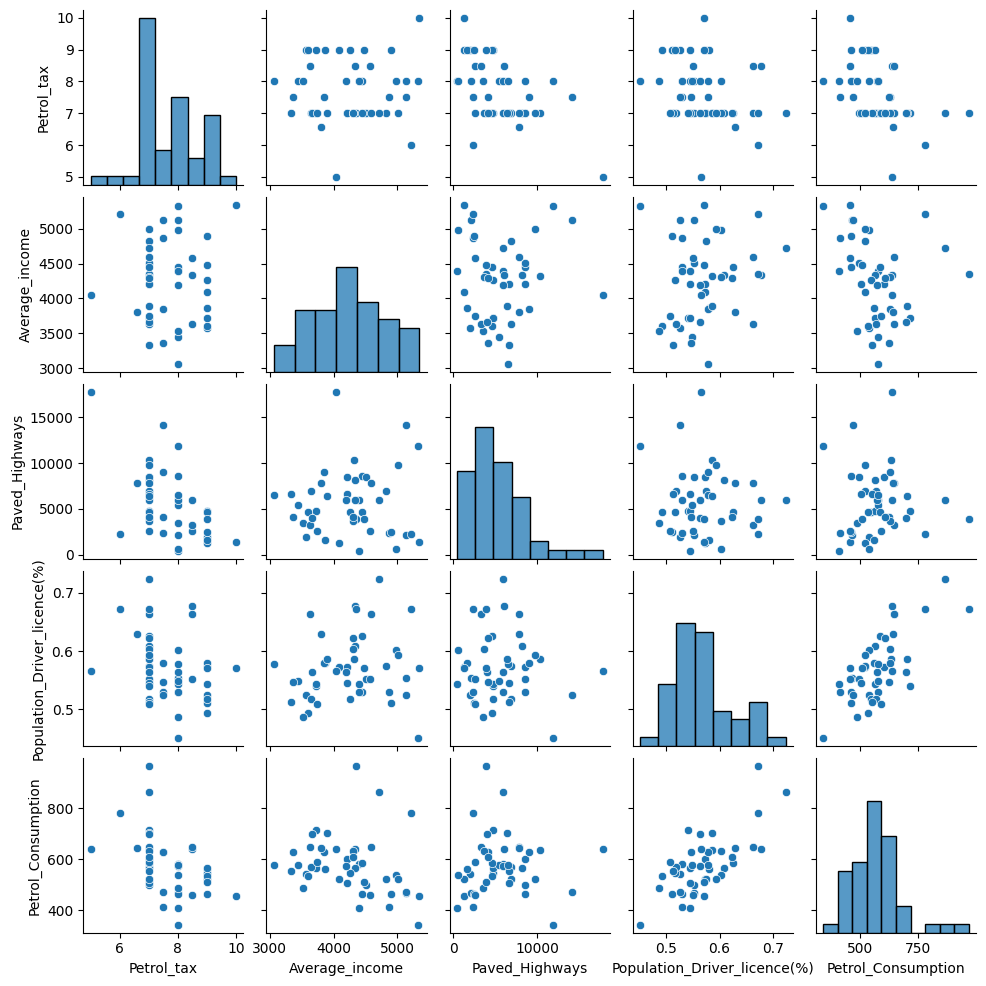

In [4]:
sns.pairplot(df,height=2)

## Method of correlation:

- Pearson : standard correlation coefficient

- Kendall : Kendall Tau correlation coefficient

- Spearman : Spearman rank correlatio

## Pearson

In [5]:
corr = df.corr(numeric_only=True) # Default Pearson
corr

,Petrol_tax,Average_income,Paved_Highways,Population_Driver_licence(%),Petrol_Consumption
Petrol_tax,1.000000,0.012665,-0.522130,-0.288037,-0.451280
Average_income,0.012665,1.000000,0.050163,0.157070,-0.244862
Paved_Highways,-0.522130,0.050163,1.000000,-0.064129,0.019042
Population_Driver_licence(%),-0.288037,0.157070,-0.064129,1.000000,0.698965
Petrol_Consumption,-0.451280,-0.244862,0.019042,0.698965,1.000000


<Axes: >

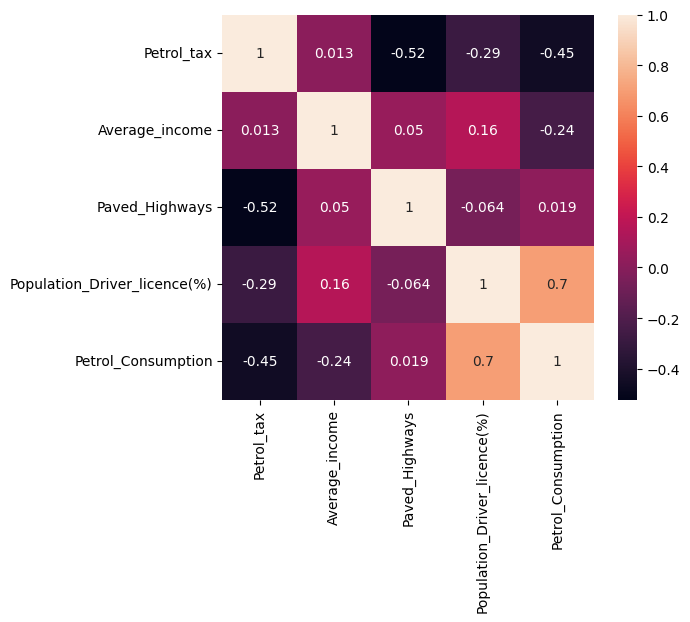

In [7]:
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True)

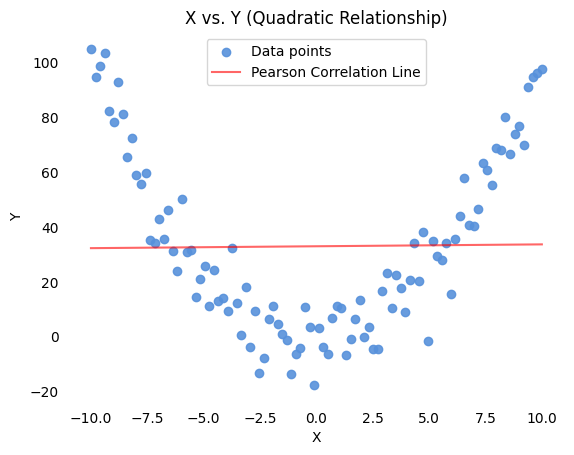

In [8]:
import numpy as np
from scipy.stats import pearsonr

# Generating quadratic data
np.random.seed(42)
X = np.linspace(-10, 10, 100)
Y = X**2 + np.random.normal(0, 10, size=len(X))

# Calculate Pearson correlation coefficient
pearson_corr, _ = pearsonr(X, Y)

m, b = np.polyfit(X, Y, 1)  # Fit a linear regression line

# Scatter plot
fig, ax = plt.subplots()
ax.scatter(X, Y, color=sns.color_palette("hls",24)[14], alpha=.9, label='Data points')
plt.plot(X, m * X + b, color='red', alpha=.6, label='Pearson Correlation Line')
plt.title("X vs. Y (Quadratic Relationship)")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend(loc='upper center')
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.xaxis.set_ticks_position('none')
ax.yaxis.set_ticks_position('none')

## Spearman

In [9]:
corr_spearman = df.corr(numeric_only=True,method='spearman')
corr_spearman

,Petrol_tax,Average_income,Paved_Highways,Population_Driver_licence(%),Petrol_Consumption
Petrol_tax,1.000000,-0.018410,-0.462443,-0.348757,-0.530718
Average_income,-0.018410,1.000000,-0.024263,0.206390,-0.355898
Paved_Highways,-0.462443,-0.024263,1.000000,0.021581,0.162043
Population_Driver_licence(%),-0.348757,0.206390,0.021581,1.000000,0.596596
Petrol_Consumption,-0.530718,-0.355898,0.162043,0.596596,1.000000


<Axes: >

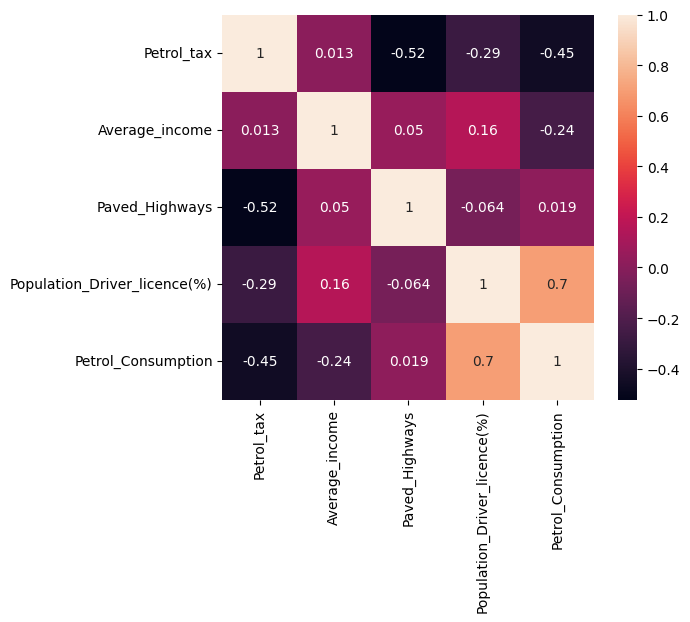

In [13]:
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True)

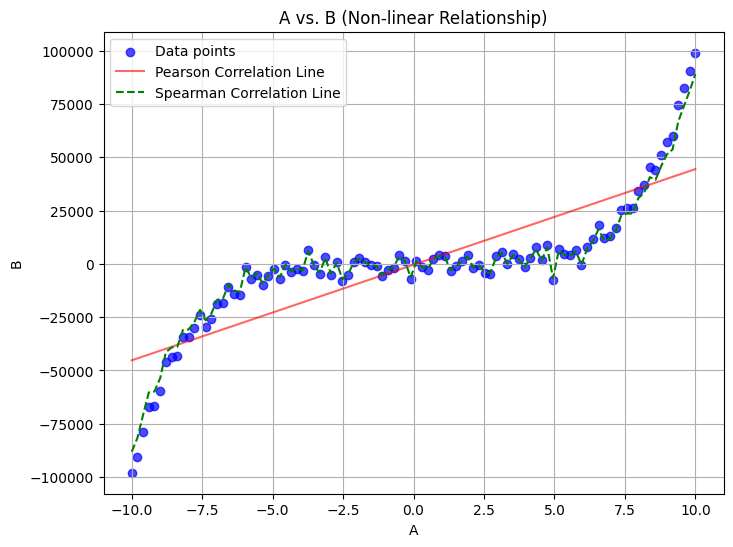

In [14]:
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

# Generating non-linear data
np.random.seed(42)
A = np.linspace(-10, 10, 100)
B = A**5 + np.random.normal(0, 4000, size=len(A))

# Calculate Spearman correlation coefficient
spearman_corr, _ = spearmanr(A, B)

# Fit a linear regression line for Pearson correlation
m, b = np.polyfit(A, B, 1)

# Scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(A, B, color='blue', alpha=0.7, label='Data points')
plt.plot(A, m * A + b, color='red', alpha=0.6, label='Pearson Correlation Line')
plt.title("A vs. B (Non-linear Relationship)")
plt.xlabel("A")
plt.ylabel("B")
plt.legend()

# Calculate and plot Spearman correlation line
sorted_indices = np.argsort(A)
sorted_A = A[sorted_indices]
sorted_B = B[sorted_indices]
plt.plot(sorted_A, spearman_corr * sorted_B + (1 - spearman_corr) * np.mean(sorted_B), color='green', linestyle='--', label='Spearman Correlation Line')
plt.legend()

plt.grid(True)
plt.show()



<img src="https://frenzy86.s3.eu-west-2.amazonaws.com/python/pearsonspearman.png" width=600>

#Correlation Matrix with Categorical Variables

In [15]:
!pip install dython -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 102.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 101.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.4 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.4 which is incompa

In [16]:
import pandas as pd
from dython.nominal import associations

import warnings
warnings.filterwarnings('ignore')


In [17]:
!wget https://raw.githubusercontent.com/adamerose/datasets/master/pokemon.csv

--2026-04-20 12:30:16--  https://raw.githubusercontent.com/adamerose/datasets/master/pokemon.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 44028 (43K) [text/plain]
Saving to: ‘pokemon.csv’

pokemon.csv         100%[===================>]  43.00K  --.-KB/s    in 0.01s   

2026-04-20 12:30:16 (3.59 MB/s) - ‘pokemon.csv’ saved [44028/44028]



In [18]:
df= pd.read_csv('pokemon.csv')
df

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,719,Diancie,Rock,Fairy,600,50,100,150,100,150,50,6,True
796,719,DiancieMega Diancie,Rock,Fairy,700,50,160,110,160,110,110,6,True
797,720,HoopaHoopa Confined,Psychic,Ghost,600,80,110,60,150,130,70,6,True
798,720,HoopaHoopa Unbound,Psychic,Dark,680,80,160,60,170,130,80,6,True


We can use the function identify_nominal_columns(dataset) of the dython library to identify the categorical variables in the dataset.

In [19]:
from dython.nominal import identify_nominal_columns

categorical_features=identify_nominal_columns(df)
categorical_features

['Name', 'Type 1', 'Type 2']

associations function returns a dictionary that contains:
- ‘corr’ as key : A DataFrame of the correlation between all features.
- ‘ax’ as value: A matplotlib axe which contains the correlation heatmap.

Firstly, Let’s find the correlation matrix for the whole pokemon dataset.

In [20]:
complete_correlation= associations(df, filename= 'complete_correlation.png', figsize=(10,10))

ImportError: cannot import name 'Pandas4Warning' from 'pandas.errors' (/usr/local/lib/python3.12/dist-packages/pandas/errors/__init__.py)

In [ ]:
df_complete_corr=complete_correlation['corr']
df_complete_corr.dropna(axis=1, how='all').dropna(axis=0, how='all')\
                                            .style.background_gradient(cmap='coolwarm', axis=None)\
                                            .set_precision(2)

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
#,1.00,1.00,0.30,0.34,0.12,0.10,0.10,0.09,0.09,0.09,0.01,0.98,0.15
Name,1.00,1.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
Type 1,0.30,0.00,1.00,0.20,0.30,0.25,0.34,0.44,0.45,0.27,0.31,0.25,0.34
Type 2,0.34,0.00,0.20,1.00,0.30,0.23,0.33,0.38,0.29,0.23,0.35,0.31,0.20
Total,0.12,1.00,0.30,0.30,1.00,0.62,0.74,0.61,0.75,0.72,0.58,0.05,0.50
HP,0.10,1.00,0.25,0.23,0.62,1.00,0.42,0.24,0.36,0.38,0.18,0.06,0.27
Attack,0.10,1.00,0.34,0.33,0.74,0.42,1.00,0.44,0.40,0.26,0.38,0.05,0.35
Defense,0.09,1.00,0.44,0.38,0.61,0.24,0.44,1.00,0.22,0.51,0.02,0.04,0.25
Sp. Atk,0.09,1.00,0.45,0.29,0.75,0.36,0.40,0.22,1.00,0.51,0.47,0.04,0.45
Sp. Def,0.09,1.00,0.27,0.23,0.72,0.38,0.26,0.51,0.51,1.00,0.26,0.03,0.36


## Correlation Matrix of Categorical Variables Only.

In [ ]:
selected_column= df[categorical_features]
categorical_df = selected_column.copy()
categorical_df

,Name,Type 1,Type 2
0,Bulbasaur,Grass,Poison
1,Ivysaur,Grass,Poison
2,Venusaur,Grass,Poison
3,VenusaurMega Venusaur,Grass,Poison
4,Charmander,Fire,NaN
...,...,...,...
795,Diancie,Rock,Fairy
796,DiancieMega Diancie,Rock,Fairy
797,HoopaHoopa Confined,Psychic,Ghost
798,HoopaHoopa Unbound,Psychic,Dark


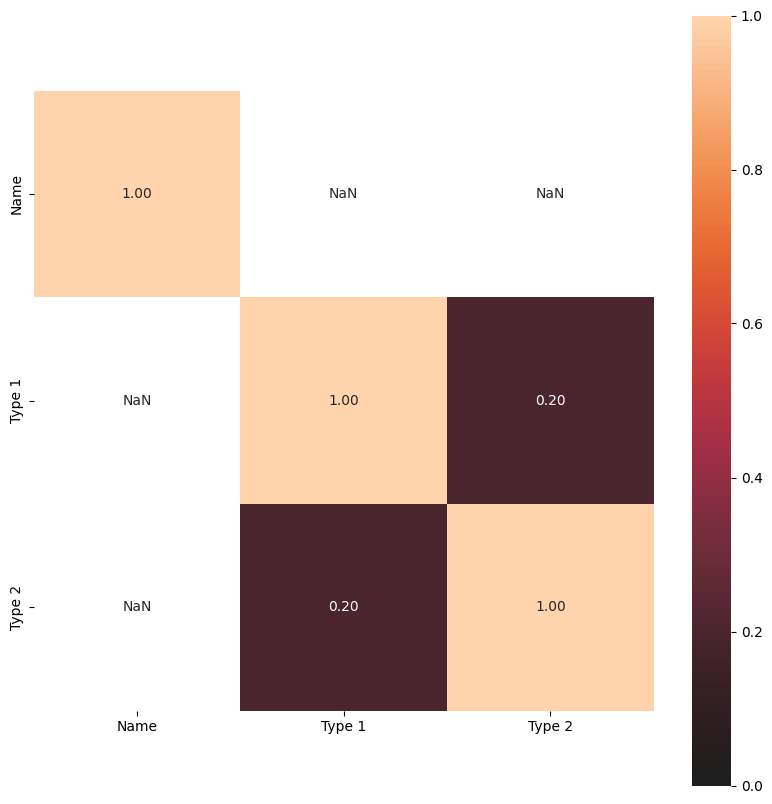

In [ ]:
categorical_correlation= associations(categorical_df, filename= 'categorical_correlation.png', figsize=(10,10))